## Задача по сегментации изображения людей на фотографии

#### для решения задачи будем использовать сети, основанные на R-CNN, а также SSD и YOLO

датасет с изображениями COCO_2017

In [1]:
import os
import json
import torch
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings

In [2]:
# Определение устройства (GPU или CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### Загрузка данных

In [3]:
# пути к данным
data_dir = './coco_2017'
train_img_dir = os.path.join(data_dir, 'train2017', 'img')
train_ann_dir = os.path.join(data_dir, 'train2017', 'ann')
val_img_dir = os.path.join(data_dir, 'val2017', 'img')
val_ann_dir = os.path.join(data_dir, 'val2017', 'ann')

In [4]:
# вывод типов аннотаций 
annotation_names = set()

for ann_file in os.listdir(train_ann_dir):
    if ann_file.endswith('.json'):
        with open(os.path.join(train_ann_dir, ann_file), 'r') as f:
            data = json.load(f)
            if 'objects' in data:
                for obj in data['objects']:
                    if 'classTitle' in obj:
                        annotation_names.add(obj['classTitle'])

for ann_file in os.listdir(val_ann_dir):
    if ann_file.endswith('.json'):
        with open(os.path.join(val_ann_dir, ann_file), 'r') as f:
            data = json.load(f)
            if 'objects' in data:
                for obj in data['objects']:
                    if 'classTitle' in obj:
                        annotation_names.add(obj['classTitle'])

print("названия аннотаций (classTitle):")
for name in sorted(annotation_names):
    print(name)

названия аннотаций (classTitle):
airplane
apple
backpack
banana
baseball bat
baseball glove
bear
bed
bench
bicycle
bird
boat
book
bottle
bowl
broccoli
bus
cake
car
carrot
cat
cell phone
chair
clock
couch
cow
cup
dining table
dog
donut
elephant
fire hydrant
fork
frisbee
giraffe
hair drier
handbag
horse
hot dog
keyboard
kite
knife
laptop
microwave
motorcycle
mouse
orange
oven
parking meter
person
pizza
potted plant
refrigerator
remote
sandwich
scissors
sheep
sink
skateboard
skis
snowboard
spoon
sports ball
stop sign
suitcase
surfboard
teddy bear
tennis racket
tie
toaster
toilet
toothbrush
traffic light
train
truck
tv
umbrella
vase
wine glass
zebra


In [6]:
# смотрим аннотации в train, val (нам надо person)
train_total_images = 0
train_images_with_people = 0
train_total_people = 0
train_classes_count = defaultdict(int)
train_annotation_types = defaultdict(int)

# Анализ train аннотаций
for ann_file in os.listdir(train_ann_dir):
    if not ann_file.endswith('.json'):
        continue
        
    train_total_images += 1
    with open(os.path.join(train_ann_dir, ann_file), 'r') as f:
        data = json.load(f)
    
    people_in_image = 0
    for obj in data['objects']:
        train_classes_count[obj['classTitle'].lower()] += 1
        train_annotation_types[obj['geometryType']] += 1
        
        if obj['classTitle'].lower() == 'person':
            people_in_image += 1
            
    if people_in_image > 0:
        train_images_with_people += 1
        train_total_people += people_in_image

val_total_images = 0
val_images_with_people = 0
val_total_people = 0
val_classes_count = defaultdict(int)
val_annotation_types = defaultdict(int)

# Анализ val аннотаций
for ann_file in os.listdir(val_ann_dir):
    if not ann_file.endswith('.json'):
        continue
        
    val_total_images += 1
    with open(os.path.join(val_ann_dir, ann_file), 'r') as f:
        data = json.load(f)
    
    people_in_image = 0
    for obj in data['objects']:
        val_classes_count[obj['classTitle'].lower()] += 1
        val_annotation_types[obj['geometryType']] += 1
        
        if obj['classTitle'].lower() == 'person':
            people_in_image += 1
            
    if people_in_image > 0:
        val_images_with_people += 1
        val_total_people += people_in_image

print(f"Тренировочные данные:")
print(f"- Всего изображений: {train_total_images}")
print(f"- Изображений с людьми: {train_images_with_people}")
print(f"- Всего людей: {train_total_people}")

print(f"\nВалидационные данные:")
print(f"- Всего изображений: {val_total_images}")
print(f"- Изображений с людьми: {val_images_with_people}")
print(f"- Всего людей: {val_total_people}")

Тренировочные данные:
- Всего изображений: 974
- Изображений с людьми: 574
- Всего людей: 5944

Валидационные данные:
- Всего изображений: 36
- Изображений с людьми: 16
- Всего людей: 120


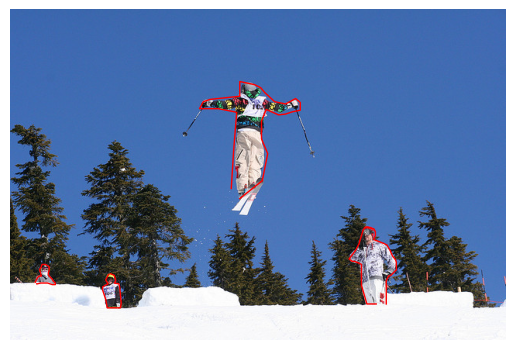

In [7]:
# визуализация с маской
def show_mask(img_path, ann_path):
    img = plt.imread(img_path)
    with open(ann_path) as f:
        ann = json.load(f)
    
    plt.imshow(img)
    for obj in ann['objects']:
        if obj['classTitle'] == 'person' and obj['geometryType'] == 'polygon':
            exterior = np.array(obj['points']['exterior'])
            plt.plot(exterior[:, 0], exterior[:, 1], 'r-', linewidth=1)
    plt.axis('off')
    plt.show()

# пример для первого валидационного изображения с человеком
val_img_with_person = [f for f in os.listdir(val_ann_dir) if f.endswith('.json')][0]
img_name = val_img_with_person.replace('.json', '')
show_mask(
    os.path.join(val_img_dir, img_name),
    os.path.join(val_ann_dir, val_img_with_person))

In [8]:
# класс CustomCocoDataset, который наследует от Dataset, и предназначен для работы с набором данных, содержащим изображения и аннотации
class CustomCocoDataset(Dataset):
    # Принимаеv на вход директории с изображениями (img_dir) и аннотациями (ann_dir)
    def __init__(self, img_dir, ann_dir, transform=None, target_size=(512, 512)):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.transform = transform
        self.target_size = target_size
        
        # Собираем только изображения с аннотациями людей
        self.img_files = [f for f in os.listdir(img_dir) 
                         if f.endswith(('.jpg', '.jpeg', '.png')) 
                         and self._has_person(os.path.join(ann_dir, f"{f}.json"))]
        
        print(f"Found {len(self.img_files)} valid image-annotation pairs with persons")
    # Проверяеv, есть ли в аннотациях хотя бы один объект с классом "person"
    def _has_person(self, ann_path):
        if not os.path.exists(ann_path):
            return False
            
        with open(ann_path) as f:
            try:
                ann_data = json.load(f)
                return any(obj.get('classTitle') == 'person' for obj in ann_data.get('objects', []))
            except:
                return False
    # считаем количество загруженных изображений
    def __len__(self):
        return len(self.img_files)
    
    # Загружаем изображение по индексу и соответствующие аннотации из JSON-файла
    # преобразуем изображение в формат RGB, изменяем его размер до target_size 
    # нормализуем значения пикселей и преобразуем их в формат float32
    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        ann_path = os.path.join(self.ann_dir, f"{img_name}.json")
        
        try:
            # Загрузка изображения
            img = cv2.imread(img_path)
            if img is None:
                raise ValueError(f"Failed to load image: {img_path}")
                
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            original_h, original_w = img.shape[:2]
            img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)
            img = img / 255.0
            img = img.astype(np.float32)  # преобразование в float32
            
            # Загрузка аннотаций
            with open(ann_path) as f:
                ann_data = json.load(f)
            
            boxes = []
            labels = []
            masks = []
            areas = []
            iscrowd = []
            
            for obj in ann_data.get('objects', []):
                if obj.get('classTitle') == 'person':
                    try:
                        points = obj.get('points', {})
                        exterior = points.get('exterior', [])
                        
                        if len(exterior) < 2:
                            continue
                            
                        # Обработка прямоугольников и полигонов
                        if obj.get('geometryType') == 'rectangle':
                            x1, y1 = exterior[0]
                            x2, y2 = exterior[1]
                            bbox = [x1, y1, x2, y2]
                            area = (x2 - x1) * (y2 - y1)
                            mask = np.zeros((original_h, original_w), dtype=np.uint8)
                            cv2.rectangle(mask, (x1, y1), (x2, y2), 1, -1)
                            
                        elif obj.get('geometryType') == 'polygon':
                            pts = np.array(exterior, np.int32)
                            x, y, w, h = cv2.boundingRect(pts)
                            bbox = [x, y, x + w, y + h]
                            area = cv2.contourArea(pts)
                            mask = np.zeros((original_h, original_w), dtype=np.uint8)
                            cv2.fillPoly(mask, [pts], 1)
                        
                        # Масштабирование
                        scale_x = self.target_size[0] / original_w
                        scale_y = self.target_size[1] / original_h
                        bbox = [bbox[0]*scale_x, bbox[1]*scale_y, 
                                bbox[2]*scale_x, bbox[3]*scale_y]
                        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)
                        
                        boxes.append(bbox)
                        masks.append(mask)
                        labels.append(1)  # Класс 'person'
                        areas.append(area)
                        iscrowd.append(0)
                        
                    except Exception as e:
                        print(f"Error processing object in {img_name}: {e}")
                        continue
            
            # Создаем target
            target = {
                'boxes': torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32),
                'labels': torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros(0, dtype=torch.int64),
                'masks': torch.as_tensor(np.stack(masks), dtype=torch.uint8) if masks else torch.zeros((0, *self.target_size), dtype=torch.uint8),
                'image_id': torch.tensor([idx], dtype=torch.int64),
                'area': torch.as_tensor(areas, dtype=torch.float32) if areas else torch.zeros(0, dtype=torch.float32),
                'iscrowd': torch.as_tensor(iscrowd, dtype=torch.uint8) if iscrowd else torch.zeros(0, dtype=torch.uint8)
            }
            
            if self.transform:
                img = self.transform(img)
                
            return img, target
            
        except Exception as e:
            print(f"Error loading {img_name}: {e}")
            # Возвращаем пустые данные
            img = torch.zeros((3, *self.target_size), dtype=torch.float32)
            target = {
                'boxes': torch.zeros((0, 4), dtype=torch.float32),
                'labels': torch.zeros(0, dtype=torch.int64),
                'masks': torch.zeros((0, *self.target_size), dtype=torch.uint8),
                'image_id': torch.tensor([-1], dtype=torch.int64),
                'area': torch.zeros(0, dtype=torch.float32),
                'iscrowd': torch.zeros(0, dtype=torch.uint8)
            }
            return img, target

In [9]:
# Трансформации и создание датасетов
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float32),  # Явное указание типа float32 т.к. модель для обучения ожидает этот тип данных
])

# Создание датасетов
train_dataset = CustomCocoDataset(train_img_dir, train_ann_dir, transform=transform)
val_dataset = CustomCocoDataset(val_img_dir, val_ann_dir, transform=transform)


Found 574 valid image-annotation pairs with persons
Found 16 valid image-annotation pairs with persons


In [10]:
# функция для объединения батча
def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    
    # конвертируем все изображения в float32
    images = [img.float() if img.dtype == torch.float64 else img for img in images]
    
    return images, targets

In [11]:
# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
    #num_workers=4
    #pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
    #num_workers=4
    #pin_memory=True if torch.cuda.is_available() else False
)

In [12]:
# размеры
print(f"dataset size: {len(train_dataset)}")
print(f"Calculated batches: {len(train_loader)}")

Real dataset size: 574
Calculated batches: 72


#### Увеличение размера batch_size и уменьшение шага lr=0.005 ухудшает итоговые метрики

In [13]:
# Инициализация модели RCNN
model = maskrcnn_resnet50_fpn(pretrained=True)
num_classes = 2  # person + background

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

# оптимизатор
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

model.to(device)


C:\Users\losev-ml\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\losev-ml\AppData\Local\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [14]:
# проверка одного батча
images, targets = next(iter(train_loader))
print("Проверка формата:")
print(f"Количество изображений: {len(images)}")
print(f"Размер изображения: {images[0].shape}")
print(f"\nКоличество таргетов: {len(targets)}")
print(f"Ключи в таргете: {targets[0].keys()}")
print(f"Форма boxes: {targets[0]['boxes'].shape}")
print(f"Форма masks: {targets[0]['masks'].shape}")
print(f"Форма labels: {targets[0]['labels'].shape}")

Проверка формата:
Количество изображений: 8
Размер изображения: torch.Size([3, 512, 512])

Количество таргетов: 8
Ключи в таргете: dict_keys(['boxes', 'labels', 'masks', 'image_id', 'area', 'iscrowd'])
Форма boxes: torch.Size([24, 4])
Форма masks: torch.Size([24, 512, 512])
Форма labels: torch.Size([24])


#### Количество изображений в батче: 8 (соответствует batch_size)

#### Размер изображений: 3x512x512 (3 канала RGB, 512x512 пикселей)

Каждое изображение имеет соответствующий словарь с аннотациями

#### Ключи: boxes, labels, masks, image_id, area, iscrowd

Размерности всех тензоров согласованы

#### Примеры изображений

In [15]:
import matplotlib.pyplot as plt

def visualize_sample(dataset, idx):
    img, target = dataset[idx]
    img = img.permute(1, 2, 0).numpy()
    
    plt.imshow(img)
    for box in target['boxes']:
        x1, y1, x2, y2 = box
        plt.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], 'r-')
    plt.show()

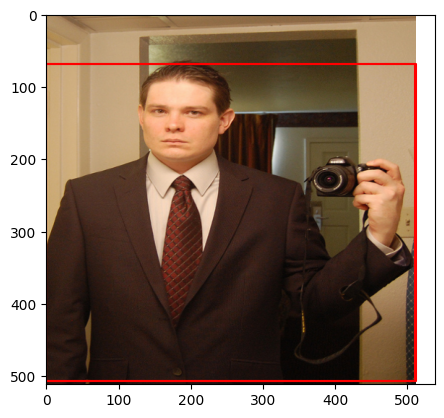

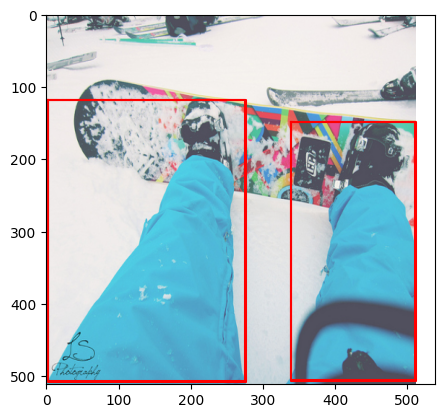

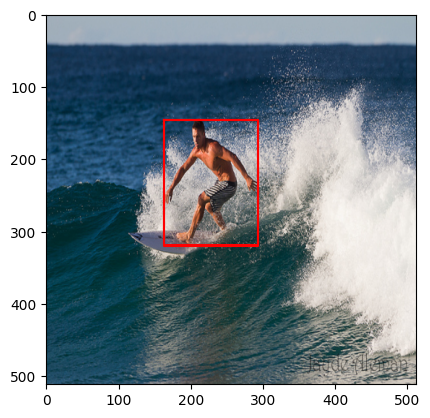

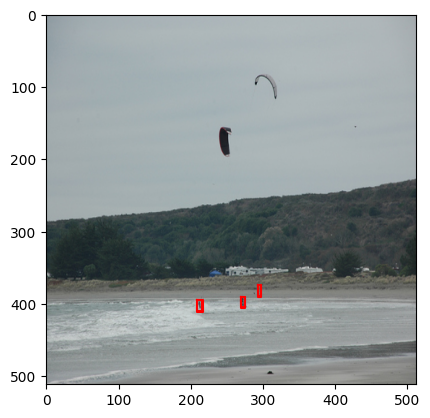

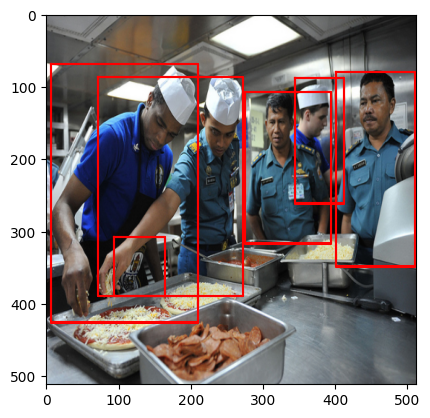

In [16]:
for i in range(min(5, len(train_dataset))):
    visualize_sample(train_dataset, i)

#### Обучение модели

In [18]:
# Обучение
num_epochs = 5


for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    
    for images, targets in progress_bar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        optimizer.zero_grad()
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        losses.backward()
        optimizer.step()
        
        epoch_loss += losses.item()
        progress_bar.set_postfix(loss=losses.item())
    
    lr_scheduler.step()
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(train_loader):.4f}')


Epoch 1/5: 100%|███████████████████████████████████████████████████████████| 72/72 [51:06<00:00, 42.59s/it, loss=0.803]


Epoch 1/5, Loss: 1.2104


Epoch 2/5: 100%|████████████████████████████████████████████████████████████| 72/72 [49:10<00:00, 40.98s/it, loss=0.82]


Epoch 2/5, Loss: 0.8476


Epoch 3/5: 100%|███████████████████████████████████████████████████████████| 72/72 [48:10<00:00, 40.14s/it, loss=0.589]


Epoch 3/5, Loss: 0.7496


Epoch 4/5: 100%|███████████████████████████████████████████████████████████| 72/72 [47:14<00:00, 39.36s/it, loss=0.423]


Epoch 4/5, Loss: 0.6781


Epoch 5/5: 100%|███████████████████████████████████████████████████████████| 72/72 [46:09<00:00, 38.46s/it, loss=0.606]

Epoch 5/5, Loss: 0.6615


In [20]:
# расчет метрик IoU, Precision, Recall
def calculate_metrics(pred_mask, gt_mask):
    # вычисляем метрики для одной пары масок 
    if pred_mask.shape != gt_mask.shape:
        pred_mask = F.interpolate(pred_mask.unsqueeze(0).unsqueeze(0), 
                                size=gt_mask.shape[-2:], 
                                mode='bilinear').squeeze()
    
    # Бинаризация
    pred_mask = (pred_mask > 0.5).float()  # можно изменить порог на 0.3
    gt_mask = gt_mask.float()
    
    intersection = (pred_mask * gt_mask).sum()
    union = (pred_mask + gt_mask).sum() - intersection
    
    # Безопасное деление
    iou = (intersection / (union + 1e-6)).item() if union > 0 else 0
    
    true_pos = intersection.item()
    false_pos = (pred_mask.sum() - intersection).item()
    false_neg = (gt_mask.sum() - intersection).item()
    
    precision = true_pos / (true_pos + false_pos + 1e-6)
    recall = true_pos / (true_pos + false_neg + 1e-6)
    
    return iou, precision, recall
    

#### Оценка модели

In [21]:
# 
def evaluate(model, val_loader, device):
    model.eval()
    metrics = {
        'val_loss': 0,
        'iou': 0,
        'precision': 0,
        'recall': 0,
        'num_samples': 0
    }
    
    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc='Validation'):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            outputs = model(images)

            try:
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
                metrics['val_loss'] += losses.item()
            except:
                pass
            
            for output, target in zip(outputs, targets):
                if len(output['masks']) == 0 or len(target['masks']) == 0:
                    continue
                
                for i, pred_mask in enumerate(output['masks']):
                    best_iou = 0
                    best_metrics = (0, 0, 0)
                    
                    for j, gt_mask in enumerate(target['masks']):
                        # Ограничиваем по меткам и вероятности
                        if output['scores'][i] < 0.5:  
                            continue
                        
                        try:
                            iou, prec, rec = calculate_metrics(pred_mask.squeeze(0), gt_mask)
                            if iou > best_iou:
                                best_iou = iou
                                best_metrics = (iou, prec, rec)
                        except Exception as e:
                            continue
                    
                    if best_iou > 0.1:
                        metrics['iou'] += best_metrics[0]
                        metrics['precision'] += best_metrics[1]
                        metrics['recall'] += best_metrics[2]
                        metrics['num_samples'] += 1
    
    if metrics['num_samples'] > 0:
        metrics['iou'] /= metrics['num_samples']
        metrics['precision'] /= metrics['num_samples']
        metrics['recall'] /= metrics['num_samples']
    
    metrics['val_loss'] /= len(val_loader)
    
    return metrics

In [201]:
# Запуск оценки
val_metrics = evaluate(model, val_loader, device)

print("\nValidation Metrics:")
print(f"Loss: {val_metrics['val_loss']:.4f}")
print(f"IoU: {val_metrics['iou']:.4f}")
print(f"Precision: {val_metrics['precision']:.4f}")
print(f"Recall: {val_metrics['recall']:.4f}")

Validation: 100%|████████████████████████████████████████████████████████████████████████| 2/2 [00:58<00:00, 29.03s/it]


Validation Metrics:
Loss: 0.0000
IoU: 0.6537
Precision: 0.8446
Recall: 0.7458


значения метрик при увеличении размера batch_size и уменьшении шага оптимизатора Learning rate
оптимизатор 

Adam тоже ухудшает метрики...

#### Validation Metrics:

Loss: 0.0000

IoU: 0.6392

Precision: 0.8186

Recall: 0.7620

#### Validation Metrics:

Loss: 0.0000

IoU: 0.6342

Precision: 0.8261

Recall: 0.7456

In [23]:
# Визуализация предсказаний
def plot_multiple_samples_with_predictions(samples, outputs, num_samples=3):

    num_samples = min(num_samples, len(samples))
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)  # для корректного индексирования при num_samples=1
    
    for i in range(num_samples):
        image, target = samples[i]
        output = outputs[i]
        
        # Оригинальное изображение
        axes[i, 0].imshow(image.permute(1, 2, 0).cpu())
        axes[i, 0].set_title(f"Sample {i+1} - Original")
        axes[i, 0].axis('off')
        
        # Истинные маски
        true_masks = target['masks'].sum(0).cpu()
        axes[i, 1].imshow(true_masks)
        axes[i, 1].set_title(f"Sample {i+1} - Ground Truth")
        axes[i, 1].axis('off')
        
        # Предсказанные маски
        pred_masks = output['masks'].sum(0).cpu().detach().numpy()
        if pred_masks.ndim == 3:
            pred_masks = pred_masks[0]
        axes[i, 2].imshow(pred_masks > 0.5, cmap='gray')
        axes[i, 2].set_title(f"Sample {i+1} - Prediction")
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

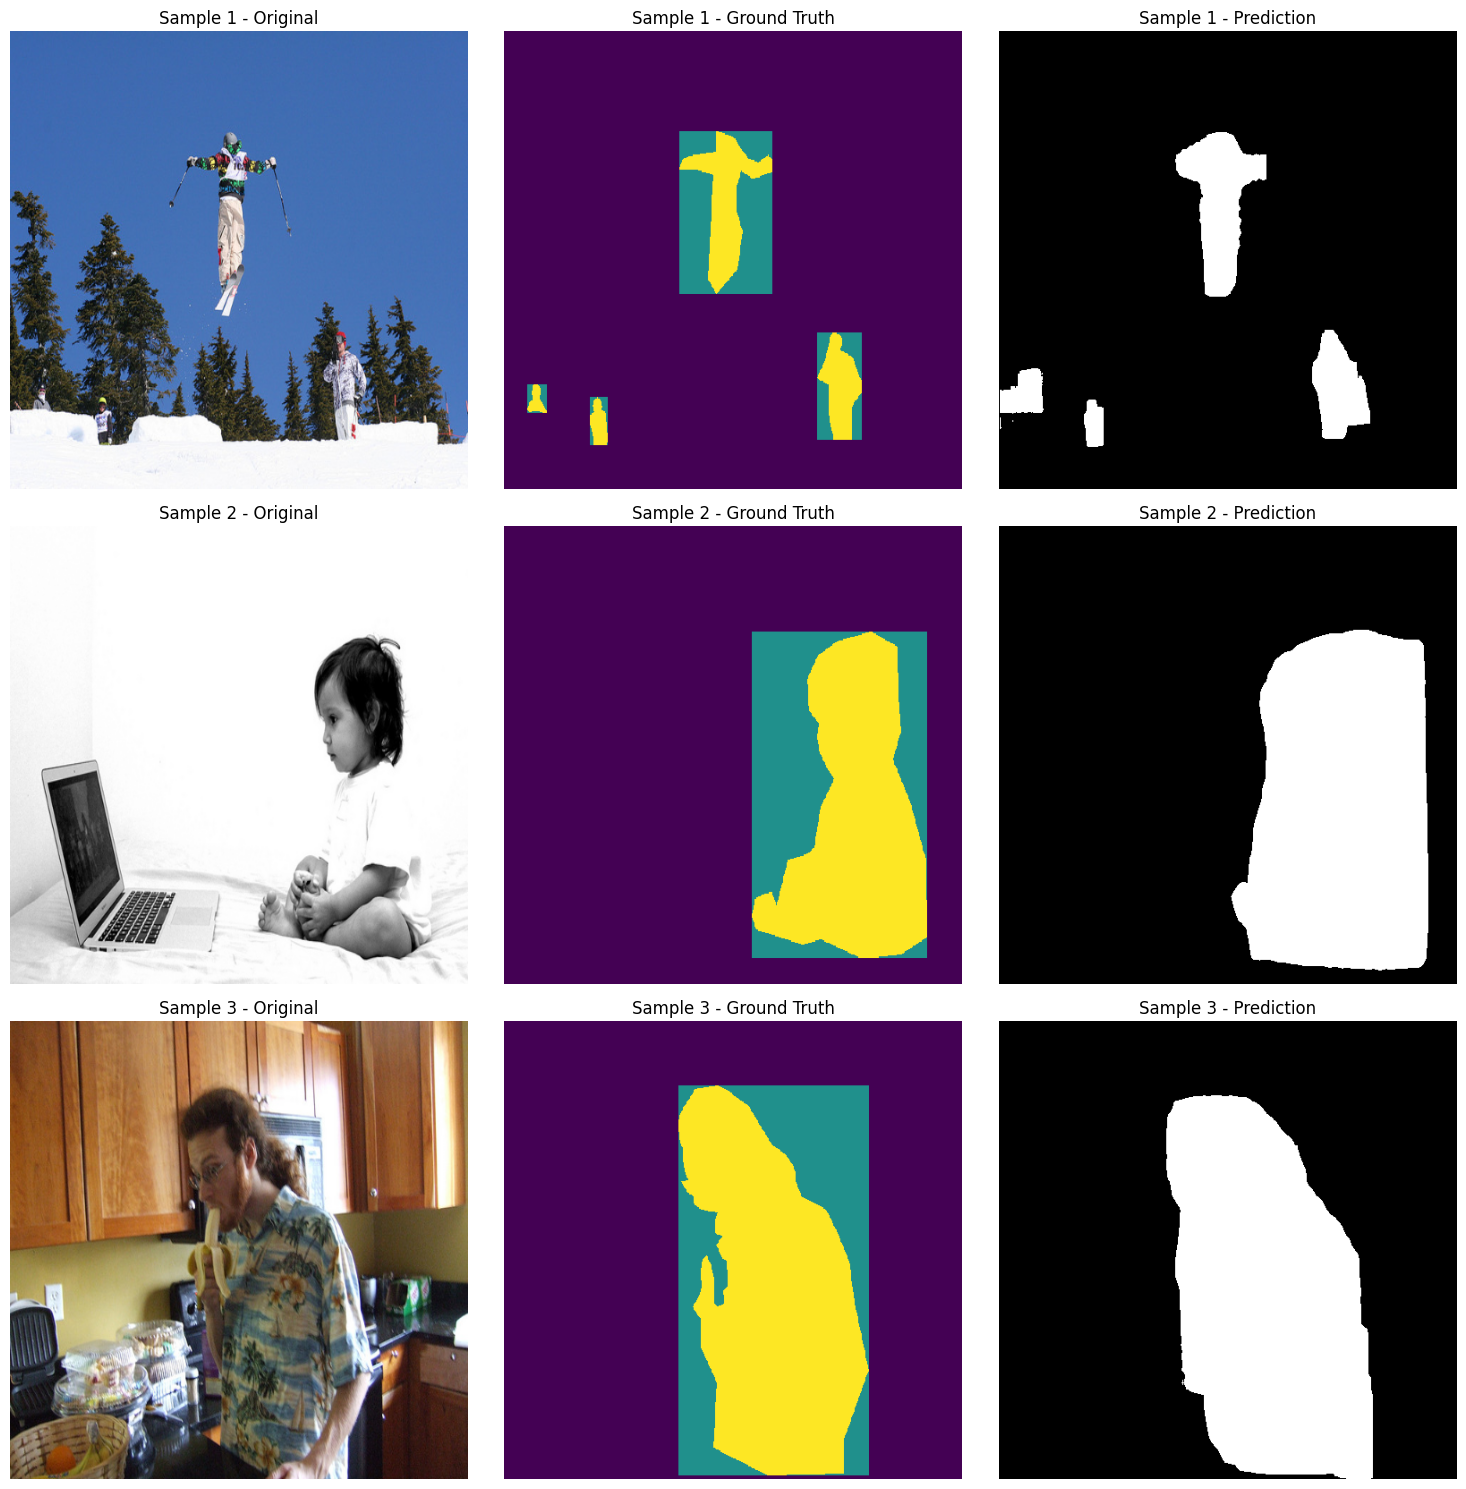

In [296]:
# получим несколько образцов и предсказаний
num_samples_to_show = 3
sample_indices = [0, 1, 4]  # или можно выбрать другие индексы

# данные для визуализации
sample_images = []
sample_targets = []
sample_outputs = []

for idx in sample_indices:
    image, target = val_dataset[idx]  # или train_dataset
    # получаем предсказание модели для этого изображения
    with torch.no_grad():
        output = model([image.to(device)])
    
    sample_images.append(image)
    sample_targets.append(target)
    sample_outputs.append(output[0])  # output - это список с одним элементом для одного изображения

# визуализируем
plot_multiple_samples_with_predictions(
    list(zip(sample_images, sample_targets)),
    sample_outputs,
    num_samples=num_samples_to_show
)

#### Подготовка данных для модели SSD

In [22]:
import os
import json
import torch
import numpy as np
import cv2
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDClassificationHead
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm
import torch.nn.functional as F

In [4]:
# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
# Пути к данным
data_dir = './coco_2017'
train_img_dir = os.path.join(data_dir, 'train2017', 'img')
train_ann_dir = os.path.join(data_dir, 'train2017', 'ann')
val_img_dir = os.path.join(data_dir, 'val2017', 'img')
val_ann_dir = os.path.join(data_dir, 'val2017', 'ann')

In [6]:
# Загрузка изображения и аннотаций для SSD
def load_image_and_annotations(img_path, ann_path, target_size=(300, 300)):
    # Загрузка изображения
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Failed to load image: {img_path}")
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_h, original_w = img.shape[:2]
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)
    img = img / 255.0
    img = img.astype(np.float32)
    
    # Загрузка аннотаций
    with open(ann_path) as f:
        ann_data = json.load(f)
    
    boxes = []
    labels = []
    areas = []
    iscrowd = []
    
    for obj in ann_data.get('objects', []):
        if obj.get('classTitle') == 'person':
            points = obj.get('points', {})
            exterior = points.get('exterior', [])
            
            if len(exterior) < 2:
                continue
                
            if obj.get('geometryType') == 'rectangle':
                x1, y1 = exterior[0]
                x2, y2 = exterior[1]
                bbox = [x1, y1, x2, y2]
                area = (x2 - x1) * (y2 - y1)
                
            elif obj.get('geometryType') == 'polygon':
                pts = np.array(exterior, np.int32)
                x, y, w, h = cv2.boundingRect(pts)
                bbox = [x, y, x + w, y + h]
                area = cv2.contourArea(pts)
            
            # Масштабирование координат
            scale_x = target_size[0] / original_w
            scale_y = target_size[1] / original_h
            bbox = [bbox[0]*scale_x, bbox[1]*scale_y, 
                    bbox[2]*scale_x, bbox[3]*scale_y]
            
            boxes.append(bbox)
            labels.append(1)  # Класс 'person'
            areas.append(area)
            iscrowd.append(0)
    
    target = {
        'boxes': torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32),
        'labels': torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros(0, dtype=torch.int64),
        'image_id': torch.tensor([hash(img_path)], dtype=torch.int64),
        'area': torch.as_tensor(areas, dtype=torch.float32) if areas else torch.zeros(0, dtype=torch.float32),
        'iscrowd': torch.as_tensor(iscrowd, dtype=torch.uint8) if iscrowd else torch.zeros(0, dtype=torch.uint8)
    }
    
    return img, target


In [7]:
# подготовка и фильтрация данных
class SSDDataset(Dataset):
    def __init__(self, img_dir, ann_dir, transform=None, target_size=(300, 300)): # 300x300 — стандартный вход для SSD300
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.transform = transform
        self.target_size = target_size
        self.samples = self._prepare_samples() # подготавливаем список валидных пар (изображение, аннотация)
    # приверяем наличие аннотаций и person
    def _prepare_samples(self):
        samples = []
        img_files = [f for f in os.listdir(self.img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))] # cписок изображений
        
        for img_file in img_files:
            img_path = os.path.join(self.img_dir, img_file)
            ann_path = os.path.join(self.ann_dir, f"{img_file}.json") # аннотация имеет то же имя, но с .json
            
            if not os.path.exists(ann_path): # пропускаем, если нет аннотации
                continue
                
            with open(ann_path) as f:
                try:
                    ann_data = json.load(f)
                    # пропускаем, если нет объектов класса 'person'
                    if not any(obj.get('classTitle') == 'person' for obj in ann_data.get('objects', [])):
                        continue
                except:
                    continue # пропускаем битые JSON-файлы
            
            samples.append((img_path, ann_path)) # добавляем в список валидных пар
        
        return samples
    #  считаем пары (изображение + аннотация)
    def __len__(self):
        return len(self.samples)
    # применяем трансормации, смотрим ошибки
    def __getitem__(self, idx): # Получаем пару по индексу
        img_path, ann_path = self.samples[idx]
        
        try:
            img, target = load_image_and_annotations(img_path, ann_path, self.target_size)
            if self.transform:
                img = self.transform(img)
            return img, target
        except Exception as e:
            print(f"Skipping {img_path}: {str(e)}")  # если ошибка — пропускаем и берём следующий элемент
            return self.__getitem__((idx + 1) % len(self))


In [8]:
# Трансформации
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Создание датасетов
train_dataset = SSDDataset(train_img_dir, train_ann_dir, transform=transform)
val_dataset = SSDDataset(val_img_dir, val_ann_dir, transform=transform)


In [9]:
# Функция для объединения батча
def collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    images = torch.stack(images, dim=0)
    return images, targets


In [10]:
# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn,
    #num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn,
    #num_workers=4
)

In [11]:
# размеры
print(f"Real dataset size: {len(train_dataset)}")
print(f"Calculated batches: {len(train_loader)}")

Real dataset size: 574
Calculated batches: 36


#### используем модель SSD300 (детекция изображений)

In [12]:
import torchvision
from torchvision.models.detection import SSD300_VGG16_Weights

In [13]:
# Инициализация модели SSD
def create_ssd_model(num_classes=2):
    # Загрузка модели с новым API (для torchvision >= 0.13)
    weights = SSD300_VGG16_Weights.COCO_V1
    model = torchvision.models.detection.ssd300_vgg16(weights=weights)
    
    in_channels = [512, 1024, 512, 256, 256, 256]  # cписок [512, 1024, 512, 256, 256, 256] — это количество каналов в каждом детекционном слое 
                                                   # они соответствуют слоям VGG16 и доп. слоям SSD, которые работают только с 300x300
    
    model.head.classification_head = torchvision.models.detection.ssd.SSDClassificationHead(
        in_channels=in_channels,
        num_anchors=model.anchor_generator.num_anchors_per_location(),
        num_classes=num_classes
    )
    
    return model

model = create_ssd_model(num_classes=2)
model.to(device)

SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [14]:
# Оптимизатор
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

####  Обучение модели

In [15]:
# Обучение
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    
    for images, targets in progress_bar:
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        optimizer.zero_grad()
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        losses.backward()
        optimizer.step()
        
        epoch_loss += losses.item()
        progress_bar.set_postfix(loss=losses.item())
    
    lr_scheduler.step()
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(train_loader):.4f}')


Epoch 1/10: 100%|███████████████████████████████████████████████████████████| 36/36 [04:11<00:00,  6.97s/it, loss=5.16]


Epoch 1/10, Loss: 6.5752


Epoch 2/10: 100%|███████████████████████████████████████████████████████████| 36/36 [04:18<00:00,  7.18s/it, loss=5.31]


Epoch 2/10, Loss: 5.1627


Epoch 3/10: 100%|███████████████████████████████████████████████████████████| 36/36 [04:38<00:00,  7.75s/it, loss=4.72]


...

Epoch 8/10, Loss: 4.4594


Epoch 9/10: 100%|███████████████████████████████████████████████████████████| 36/36 [04:39<00:00,  7.75s/it, loss=4.59]


Epoch 9/10, Loss: 4.4473


Epoch 10/10: 100%|██████████████████████████████████████████████████████████| 36/36 [04:39<00:00,  7.75s/it, loss=4.57]

Epoch 10/10, Loss: 4.4560


In [16]:
# функция расчета метрик для пары bounding boxes (предсказание и GT)
def calculate_metrics_ssd(pred_box, gt_box):
    
    # Расчет пересечения
    x_left = max(pred_box[0], gt_box[0])
    y_top = max(pred_box[1], gt_box[1])
    x_right = min(pred_box[2], gt_box[2])
    y_bottom = min(pred_box[3], gt_box[3])
    
    intersection_area = max(0, x_right - x_left) * max(0, y_bottom - y_top)
    
    # Площади прямоугольников
    pred_area = (pred_box[2] - pred_box[0]) * (pred_box[3] - pred_box[1])
    gt_area = (gt_box[2] - gt_box[0]) * (gt_box[3] - gt_box[1])
    
    union_area = pred_area + gt_area - intersection_area
    
    # Расчет метрик
    iou = intersection_area / (union_area + 1e-6)
    
    # Для Precision/Recall считаем detection как True Positive если IoU > threshold
    true_positive = 1 if iou > 0.5 else 0
    false_positive = 1 - true_positive
    false_negative = 0  # Будет пересчитано при сопоставлении с GT
    
    return iou, true_positive, false_positive, false_negative

#### Оценка модели

In [17]:
# можно iou_threshold ( 0.3-0.7) confidence_threshold (например, до 0.1)
def evaluate_ssd(model, val_loader, device, iou_threshold=0.5, confidence_threshold=0.3): 
    model.eval()
    metrics = {
        'iou': 0,
        'precision': 0,
        'recall': 0,
        'total_tp': 0,
        'total_fp': 0,
        'total_fn': 0,
        'num_images': 0
    }
    
    with torch.no_grad():
        for images, targets in val_loader:
            images = list(img.to(device) for img in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            outputs = model(images)
            metrics['num_images'] += len(images)
            
            for output, target in zip(outputs, targets):
                pred_boxes = output['boxes'].cpu().numpy()
                pred_scores = output['scores'].cpu().numpy()
                pred_labels = output['labels'].cpu().numpy()
                gt_boxes = target['boxes'].cpu().numpy()
                
                # Фильтрация предсказаний
                keep = (pred_scores > confidence_threshold) & (pred_labels == 1)
                pred_boxes = pred_boxes[keep]
                pred_scores = pred_scores[keep]
                
                # Сопоставление предсказаний с GT
                used_gt_indices = set()
                
                for pred_box in pred_boxes:
                    best_iou = 0
                    best_gt_idx = -1
                    
                    for gt_idx, gt_box in enumerate(gt_boxes):
                        if gt_idx in used_gt_indices:
                            continue
                            
                        # Расчет IoU
                        x_left = max(pred_box[0], gt_box[0])
                        y_top = max(pred_box[1], gt_box[1])
                        x_right = min(pred_box[2], gt_box[2])
                        y_bottom = min(pred_box[3], gt_box[3])
                        intersection = max(0, x_right - x_left) * max(0, y_bottom - y_top)
                        
                        pred_area = (pred_box[2]-pred_box[0])*(pred_box[3]-pred_box[1])
                        gt_area = (gt_box[2]-gt_box[0])*(gt_box[3]-gt_box[1])
                        union = pred_area + gt_area - intersection
                        iou = intersection / (union + 1e-6)
                        
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = gt_idx
                    
                    if best_iou > iou_threshold:
                        used_gt_indices.add(best_gt_idx)
                        metrics['total_tp'] += 1
                        metrics['iou'] += best_iou
                    else:
                        metrics['total_fp'] += 1
                
                metrics['total_fn'] += len(gt_boxes) - len(used_gt_indices)
    
    # Расчет итоговых метрик
    if metrics['total_tp'] > 0:
        metrics['iou'] /= metrics['total_tp']
    
    total_pred = metrics['total_tp'] + metrics['total_fp']
    metrics['precision'] = metrics['total_tp'] / (total_pred + 1e-6)
    metrics['recall'] = metrics['total_tp'] / (metrics['total_tp'] + metrics['total_fn'] + 1e-6)
    
    return metrics

In [18]:
# Проверка одного примера данных
sample_img, sample_target = val_dataset[0]
print("Image shape:", sample_img.shape)
print("Target keys:", sample_target.keys())
print("Number of persons:", len(sample_target['boxes']))
print("Boxes:", sample_target['boxes'])

Image shape: torch.Size([3, 300, 300])
Target keys: dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd'])
Number of persons: 8
Boxes: tensor([[114.3750,  65.3396, 175.7812, 172.1311],
        [114.3750,  65.3396, 175.3125, 171.4286],
        [204.8438, 197.4239, 233.9062, 267.6815],
        [204.8438, 197.4239, 233.4375, 266.9789],
        [ 55.7812, 239.5785,  67.5000, 271.1944],
        [ 55.7812, 239.5785,  67.0312, 270.4918],
        [ 15.0000, 231.1475,  27.6562, 250.1171],
        [ 15.0000, 231.1475,  27.1875, 249.4145]])


In [19]:
# Оценка модели
val_metrics = evaluate_ssd(model, val_loader, device, 
                         iou_threshold=0.5, 
                         confidence_threshold=0.3)

print("\nValidation Metrics:")
print(f"IoU: {val_metrics['iou']:.4f}")
print(f"Precision: {val_metrics['precision']:.4f}")
print(f"Recall: {val_metrics['recall']:.4f}")
print(f"True Positives: {val_metrics['total_tp']}")
print(f"False Positives: {val_metrics['total_fp']}")
print(f"False Negatives: {val_metrics['total_fn']}")


Validation Metrics:
IoU: 0.6592
Precision: 0.4643
Recall: 0.1083
True Positives: 13
False Positives: 15
False Negatives: 107


In [ ]:
Для SSD считаем IoU между bbox, а не масками

Precision = TP / (TP + FP)

Recall = TP / (TP + FN)

Порог IoU для детекции  0.5

#### Визуализация предсказаний

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].


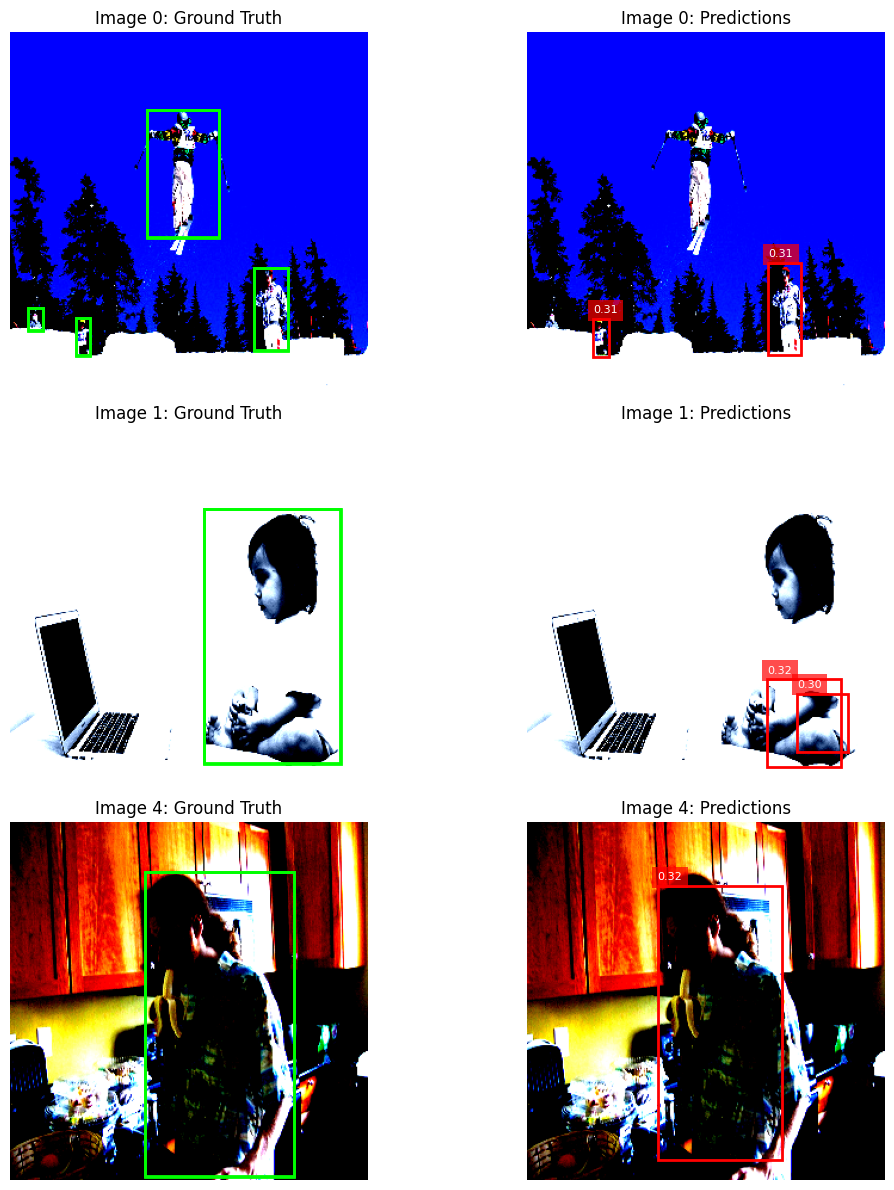

In [25]:
def visualize_selected_samples(model, dataset, device, sample_indices=None, confidence_thresh=0.3):
    import matplotlib.pyplot as plt
    import numpy as np
    import random
    
    # Если индексы не указаны, выбираем 3 случайных
    if sample_indices is None:
        sample_indices = random.sample(range(len(dataset)), min(3, len(dataset)))
    else:
        # Проверяем, что индексы в допустимом диапазоне
        sample_indices = [idx for idx in sample_indices if idx < len(dataset)]
        if len(sample_indices) == 0:
            sample_indices = random.sample(range(len(dataset)), min(3, len(dataset)))
    
    model.eval()
    num_samples = len(sample_indices)
    
    # Создаем фигуру
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = axes[np.newaxis, :]
    
    for i, idx in enumerate(sample_indices):
        # Получаем изображение и аннотации
        img, target = dataset[idx]
        img_tensor = img.unsqueeze(0).to(device)
        
        # Получаем предсказания модели
        with torch.no_grad():
            output = model(img_tensor)
        
        # Конвертируем изображение
        img_np = img.permute(1, 2, 0).cpu().numpy()
        
        # Ground Truth
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'Image {idx}: Ground Truth')
        axes[i, 0].axis('off')
        
        for box in target['boxes']:
            x1, y1, x2, y2 = map(int, box)
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                               linewidth=2, edgecolor='lime', facecolor='none')
            axes[i, 0].add_patch(rect)
        
        # Predictions
        axes[i, 1].imshow(img_np)
        axes[i, 1].set_title(f'Image {idx}: Predictions')
        axes[i, 1].axis('off')
        
        for box, score in zip(output[0]['boxes'], output[0]['scores']):
            if score > confidence_thresh:
                x1, y1, x2, y2 = map(int, box.cpu())
                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                   linewidth=2, edgecolor='red', facecolor='none')
                axes[i, 1].add_patch(rect)
                axes[i, 1].text(x1, y1-5, f'{score:.2f}', color='white', fontsize=8,
                              bbox=dict(facecolor='red', alpha=0.7, edgecolor='none'))
    
    plt.tight_layout()
    plt.show()

visualize_selected_samples(model, val_dataset, device, sample_indices=[0, 1, 4])

Архитектура: SSD - это однопроходная детекторная сеть, которая предсказывает bounding boxes и классы объектов за один проход через сеть.

Скорость: SSD работает значительно быстрее чем R-CNN.

#### Сегментация: В отличие от Mask R-CNN, SSD не выполняет сегментацию (не выдает маски объектов), только детекцию (bounding boxes).

Метрики: Для SSD мы вычисляем метрики только для bounding boxes (IoU, Precision, Recall), а не для масок сегментации.

Размер изображения: SSD обычно работает с изображениями фиксированного размера (300x300 или 512x512), в то время как R-CNN может обрабатывать изображения разного размера.

Для задач, где важна точная сегментация, SSD не очень подходит - лучше использовать Mask R-CNN или другие модели сегментации.

### Задача сегментации с использованием модели YOLOv8... 

In [13]:
import os
import json
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('TkAgg')  # Для отображения графиков
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.metrics import precision_score, recall_score, jaccard_score
import torch
from tqdm import tqdm

In [2]:
# Инициализация модели
model = YOLO(r'C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\yolov8m-seg.pt')

In [3]:
# Вывод информации о модели
print("\nИнформация о модели:")
print(f"Количество классов: {len(model.names)}")
print(f"Классы: {model.names}")
print(f"Устройство: {model.device}")

# архитектура модели
if hasattr(model, 'model'):
    print("\n Архитектура:")
    print(model.model)


Информация о модели:
Количество классов: 80
Классы: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'r

In [5]:
# Определение устройства
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
# Пути к данным
data_dir = './coco_2017'
train_img_dir = os.path.join(data_dir, 'train2017', 'img')
train_ann_dir = os.path.join(data_dir, 'train2017', 'ann')
val_img_dir = os.path.join(data_dir, 'val2017', 'img')
val_ann_dir = os.path.join(data_dir, 'val2017', 'ann')

In [6]:
# Конвертируем данные из формата COCO2017 в формат YOLO
# base_path: путь к корневой папке coco_2017
# output_dir: директория для сохранения данных в формате YOLO
def convert_custom_coco_to_yolo(base_path, output_dir):
    splits = ['train2017', 'val2017']  
    
    for split in splits:
        # Создаем директории для YOLO
        yolo_img_dir = os.path.join(output_dir, split, 'images')
        yolo_label_dir = os.path.join(output_dir, split, 'labels')
        os.makedirs(yolo_img_dir, exist_ok=True)
        os.makedirs(yolo_label_dir, exist_ok=True)
        
        # Пути к исходным данным
        img_dir = os.path.join(base_path, split, 'img')
        ann_dir = os.path.join(base_path, split, 'ann')
        
        # Получаем список файлов изображений
        img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        for img_file in tqdm(img_files, desc=f'Processing {split}'):
            img_path = os.path.join(img_dir, img_file)
            ann_path = os.path.join(ann_dir, f"{img_file}.json")
            
            # Пропускаем если нет аннотации
            if not os.path.exists(ann_path):
                continue
                
            # Читаем изображение для получения размеров
            img = cv2.imread(img_path)
            if img is None:
                continue
            h, w = img.shape[:2]
            
            # Читаем аннотации
            with open(ann_path, 'r') as f:
                ann_data = json.load(f)
            
            # Собираем все полигоны для людей
            label_lines = []
            for obj in ann_data.get('objects', []):
                if obj.get('classTitle', '').lower() == 'person':
                    points = obj.get('points', {})
                    exterior = points.get('exterior', [])
                    
                    if len(exterior) < 2:
                        continue
                    
                    # Обработка прямоугольников и полигонов
                    if obj.get('geometryType') == 'rectangle':
                        x1, y1 = exterior[0]
                        x2, y2 = exterior[1]
                        polygon = [x1, y1, x2, y1, x2, y2, x1, y2]
                    else:  # polygon
                        polygon = []
                        for point in exterior:
                            polygon.extend(point)
                    
                    # Нормализация координат для YOLO
                    normalized_poly = []
                    for i in range(0, len(polygon), 2):
                        x = polygon[i] / w
                        y = polygon[i+1] / h
                        normalized_poly.extend([x, y])
                    
                    # Формат YOLO: class_id x1 y1 x2 y2 ... xn yn
                    label_lines.append("0 " + " ".join(map(str, normalized_poly)))
            
            # Сохраняем только если есть аннотации людей
            if label_lines:
                # Копируем изображение
                shutil.copy2(img_path, os.path.join(yolo_img_dir, img_file))
                
                # Сохраняем аннотации
                label_file = os.path.splitext(img_file)[0] + '.txt'
                with open(os.path.join(yolo_label_dir, label_file), 'w') as f:
                    f.write("\n".join(label_lines))

In [58]:
# конвертируем в формат yolo
convert_custom_coco_to_yolo(
    base_path='./coco_2017',
    output_dir='./coco_yolo'
)

Processing val2017: 100%|█████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 181.79it/s]


In [60]:
# создание файла data.yaml
with open('./coco_yolo/data.yaml', 'w') as f:
    f.write("""path: ./coco_yolo
train: train2017/images
val: val2017/images
nc: 1
names: ['person']
augment: True
hsv_h: 0.015
hsv_s: 0.7
hsv_v: 0.4
degrees: 10.0
translate: 0.1
scale: 0.5
fliplr: 0.5
""")

In [7]:
# проверка, пути существуют
data_yaml_path = r'C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\data.yaml'
train_img_dir = r'C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\train2017\images'
val_img_dir = r'C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\images'

print(f"data.yaml exists: {os.path.exists(data_yaml_path)}")
print(f"Train images: {len(os.listdir(train_img_dir))}")
print(f"Val images: {len(os.listdir(val_img_dir))}")

data.yaml exists: True
Train images: 574
Val images: 16


#### обучение модели

In [10]:
model = YOLO('yolov8m-seg.pt')
# + аугментация в data.yaml
model.train(data='C:/Users/losev-ml/Desktop/Anaconda/Deep Learning/YOLO/coco_yolo/data.yaml', 
            epochs=12, 
            imgsz=640, 
            batch=8,  # Уменьшенный batch для лучшей стабильности
            augment=True,
            lr0=0.01, # Для SGD лучше подходит более высокий learning rate
            lrf=0.1,
            optimizer='SGD', #вообще 'AdamW'лучше для сегментации, но в данном случае SGD 
            momentum=0.937,  # Важно для SGD
            weight_decay=0.0005,
            mask_ratio=4  # Более детальные маски
            #augment=True  # Включение аугментации
)

Ultralytics 8.3.119  Python-3.12.7 torch-2.6.0+cpu CPU (Intel Core(TM) i7-9700 3.00GHz)
engine\trainer: task=segment, mode=train, model=yolov8m-seg.pt, data=C:/Users/losev-ml/Desktop/Anaconda/Deep Learning/YOLO/coco_yolo/data.yaml, epochs=12, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_la

train: Scanning C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\train2017\labels.cache... 574 images, 0

train: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\train2017\images\000000000459.jpg: 1 duplicate labels removed
train: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\train2017\images\000000000965.jpg: 2 duplicate labels removed
train: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\train2017\images\000000001308.jpg: 1 duplicate labels removed
train: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\train2017\images\000000005210.jpg: 3 duplicate labels removed
train: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\train2017\images\000000006640.jpg: 6 duplicate labels removed
train: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\train2017\images\000000006998.jpg: 13 duplicate labels removed
train: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\train2017\images\000000007069.jpg: 1 duplicate labels removed
train: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yo

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.30.1 ms, read: 310.8108.7 MB/s, size: 177.6 KB)


val: Scanning C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\labels.cache... 16 images, 0 back

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP

WARNING Model does not support 'augment=True', reverting to single-scale prediction.
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limitin

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP


                   all         16         62      0.902      0.645      0.744      0.554      0.869      0.677      0.728      0.509
Speed: 2.9ms preprocess, 475.9ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs\segment\train4


ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000257E3686E70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410

#### графики обучения (взял итоговые по лучшему обучению из runs/segment...)

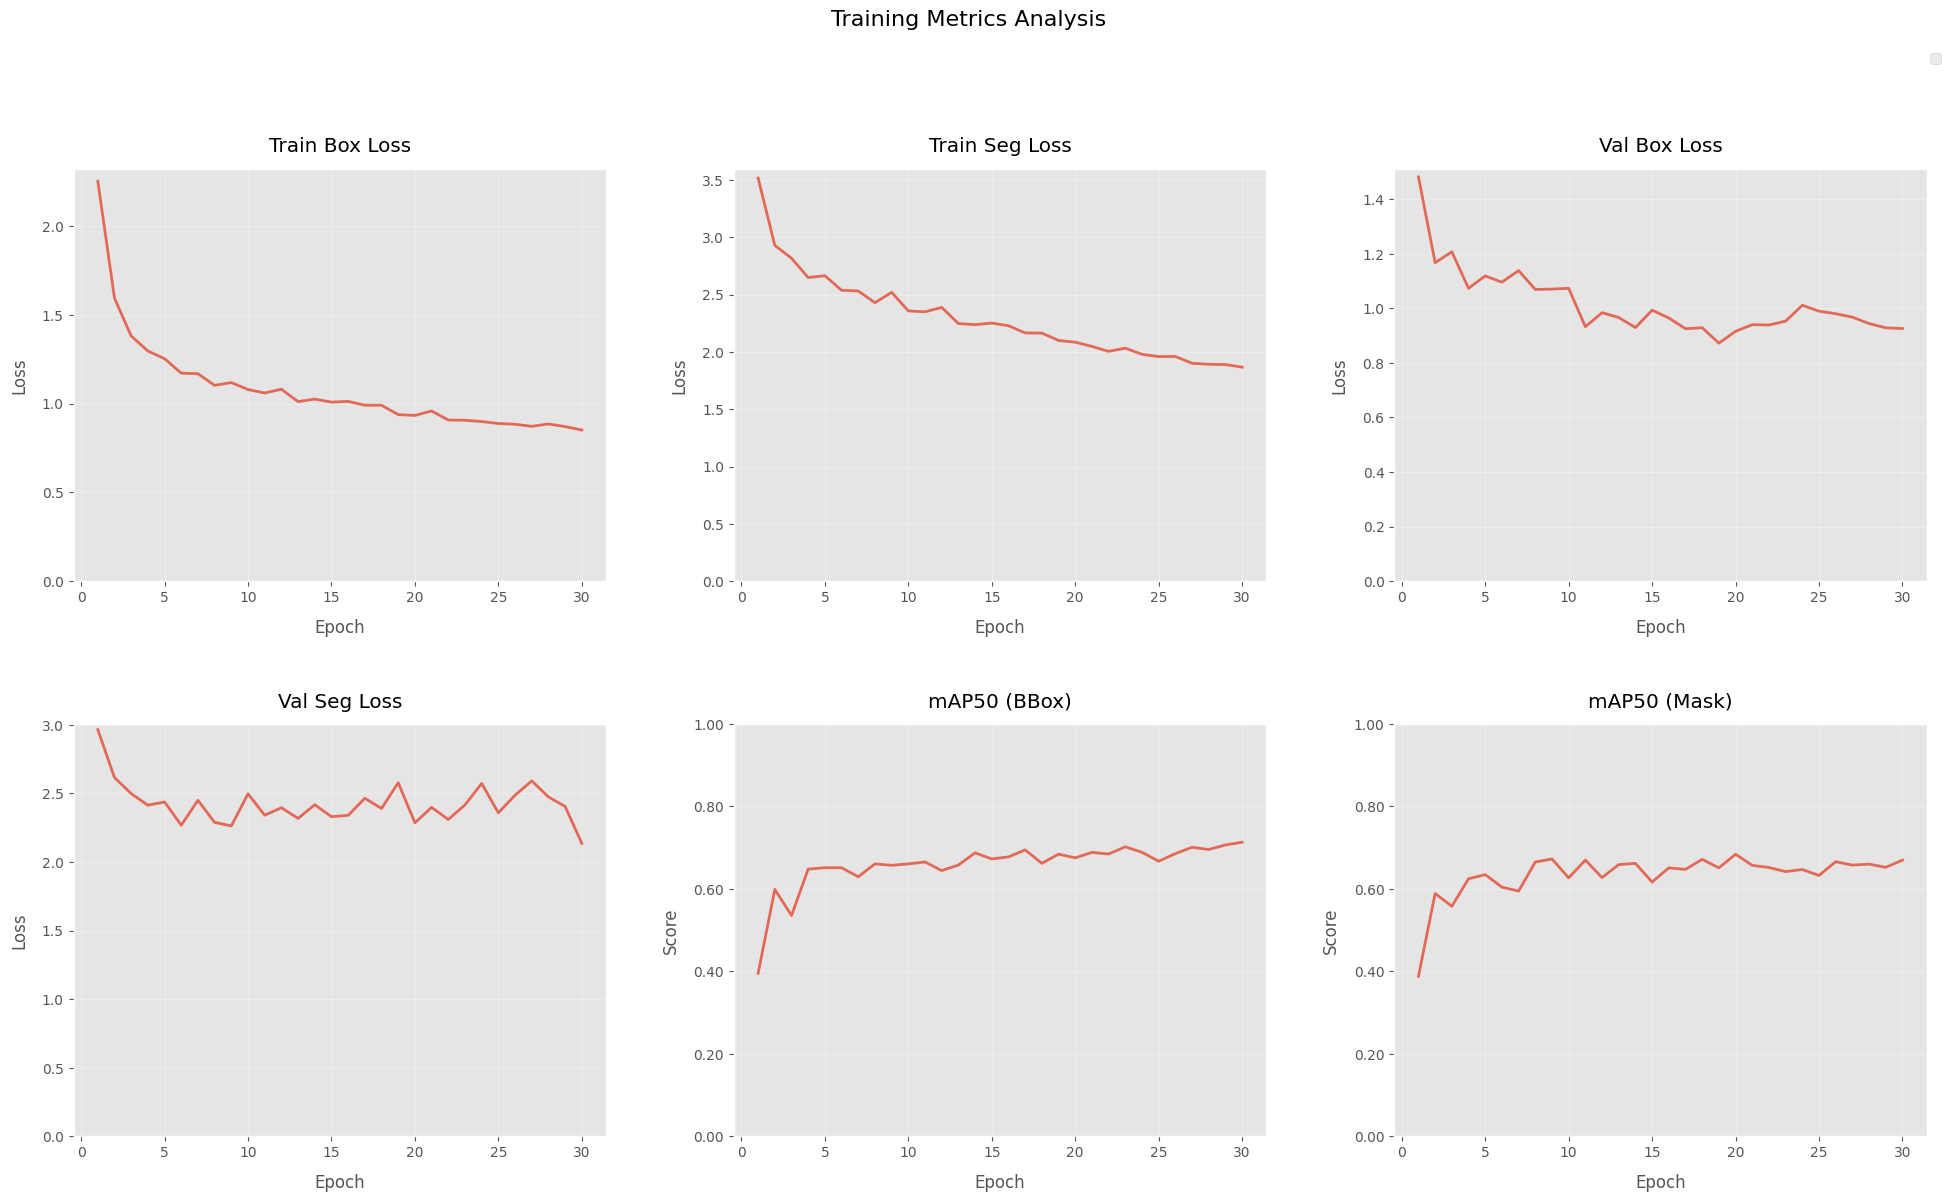

In [9]:
#%matplotlib inline  #активация inline-режима
from IPython.display import display, clear_output

plt.style.use('ggplot')

# загрузка результатов
results_csv = 'runs/segment/train/results.csv'
results = pd.read_csv(results_csv)

fig, axs = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Training Metrics Analysis', y=1.02, fontsize=16)

# словарь метрик 
metrics = {
    'train/box_loss': ('Train Box Loss', 'Loss'),
    'train/seg_loss': ('Train Seg Loss', 'Loss'),
    'val/box_loss': ('Val Box Loss', 'Loss'),
    'val/seg_loss': ('Val Seg Loss', 'Loss'),
    'metrics/mAP50(B)': ('mAP50 (BBox)', 'Score'),
    'metrics/mAP50(M)': ('mAP50 (Mask)', 'Score')
}

for idx, (col, (title, ylabel)) in enumerate(metrics.items()):
    row = idx // 3
    col_num = idx % 3
    ax = axs[row, col_num]
    
    ax.plot(results['epoch'], results[col], lw=2, alpha=0.8)
    ax.set_title(title, pad=12)
    ax.set_xlabel('Epoch', labelpad=10)
    ax.set_ylabel(ylabel, labelpad=10)
    ax.grid(True, alpha=0.3)
    
    if 'Loss' in title:
        ax.set_ylim(bottom=0)
    elif 'mAP50' in title:
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

plt.tight_layout(pad=3.0, w_pad=4.0, h_pad=4.0)

handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 0.99))

plt.show()

#### Потери (Losses):

train/box_loss - потери детекции bbox снижаются

train/seg_loss - потери сегментации снижаются

так же и на валидации (рывками)

Начальный разрыв значений между train/val может показывать переобучение однако к конца обучения значения метрик приближаются

#### Метрики точности:

metrics/mAP50(B) - для bounding box постепенно растет

metrics/mAP50(M) - для масок сегментации тоже постепенно растет (рывки значений)

необходимо увеличить колличество эпох обучения

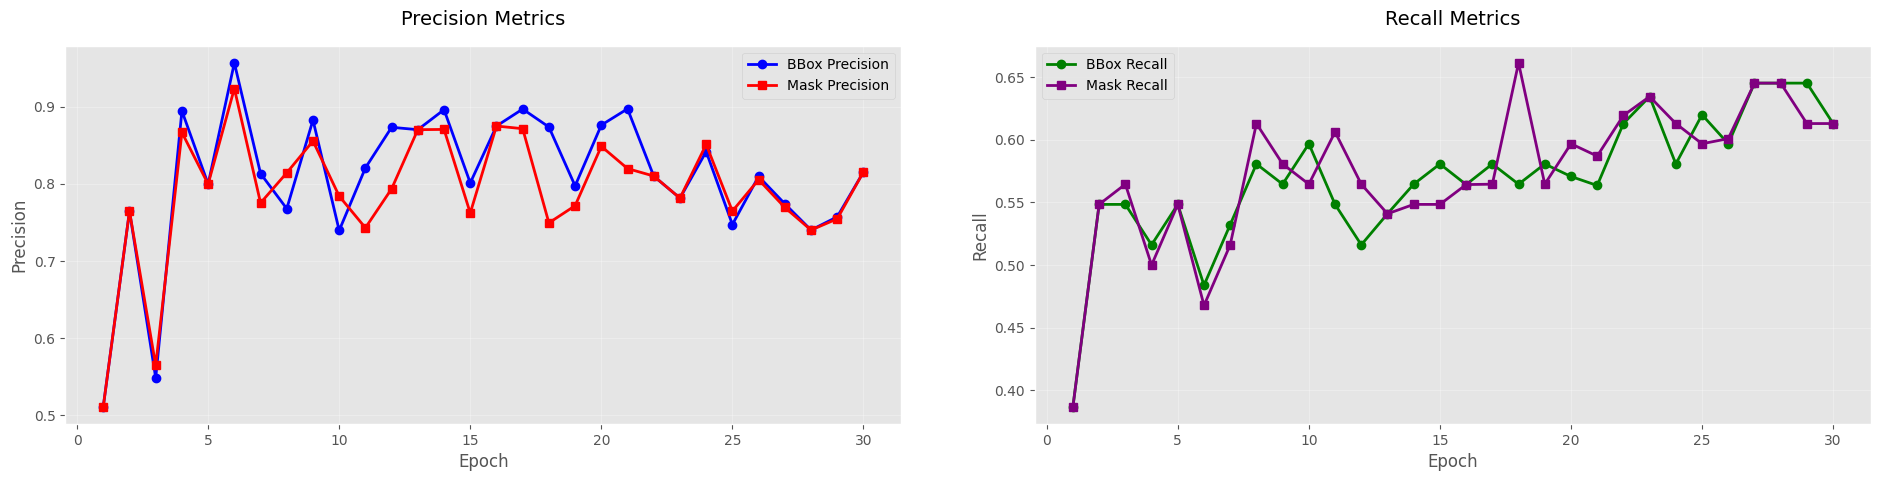

In [10]:
#%matplotlib inline  #активация inline-режима
plt.style.use('ggplot')

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

# график Precision
ax1.plot(results['epoch'], results['metrics/precision(B)'], 
        label='BBox Precision', color='blue', marker='o', linewidth=2)
ax1.plot(results['epoch'], results['metrics/precision(M)'], 
        label='Mask Precision', color='red', marker='s', linewidth=2)
ax1.set_title('Precision Metrics', fontsize=14, pad=15)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Precision', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# график Recall
ax2.plot(results['epoch'], results['metrics/recall(B)'], 
        label='BBox Recall', color='green', marker='o', linewidth=2)
ax2.plot(results['epoch'], results['metrics/recall(M)'], 
        label='Mask Recall', color='purple', marker='s', linewidth=2)
ax2.set_title('Recall Metrics', fontsize=14, pad=15)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Recall', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout(pad=5.0)
plt.show()

#### Precision постепенно начинает расти, однако Recall начинает снижаться - естественный компромисс метрик

#### Интерпретация результатов:

Хорошая модель: Потери монотонно уменьшаются, mAP хоть и медленно но растет

Возможно переобучение: Val loss "рывками" снижается при плавном уменьшении train loss однако разрыв между их конечными значениями уменьшается

Проблемы: Если метрики "скачут" - надо будет уменьшить lr0

In [82]:
# функция расчета метрик IoU, Precision и Recall
def calculate_metrics(pred_mask, gt_mask):
    
    pred_flat = pred_mask.flatten()
    gt_flat = gt_mask.flatten()
    
    # Если нет GT и предсказаний
    if np.sum(gt_flat) == 0 and np.sum(pred_flat) == 0:
        return 1.0, 1.0, 1.0  # если нет объектов и модель ничего не предсказала
    
    iou = jaccard_score(gt_flat, pred_flat)
    precision = precision_score(gt_flat, pred_flat, zero_division=0)
    recall = recall_score(gt_flat, pred_flat, zero_division=0)
    
    return iou, precision, recall

#### оценка модели

In [85]:
total_iou = 0
total_precision = 0
total_recall = 0
count = 0

for img_file in os.listdir(val_img_dir):
    img_path = os.path.join(val_img_dir, img_file)
    label_path = os.path.join(val_label_dir, os.path.splitext(img_file)[0] + '.txt')
    
    # Загрузка изображения
    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w = img.shape[:2]
    
    # Создание GT маски
    gt_mask = np.zeros((h, w), dtype=np.uint8)
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = list(map(float, line.strip().split()))
                if len(parts) < 3:  # Минимум: класс + 1 точка
                    continue
                polygon = np.array(parts[1:]).reshape(-1, 2) * [w, h]
                polygon = polygon.astype(np.int32)
                cv2.fillPoly(gt_mask, [polygon], 1)
    
    # Предсказание
    results = model(img_path)
    if not results or results[0].masks is None:
        continue
    
    # Объединение масок предсказаний (только класс 'person')
    pred_mask = np.zeros((h, w), dtype=np.uint8)
    for mask, cls in zip(results[0].masks.data.cpu().numpy(), 
                       results[0].boxes.cls.cpu().numpy()):
        if cls == 0:  # Только люди
            mask = cv2.resize(mask, (w, h))
            pred_mask = np.logical_or(pred_mask, mask > 0.1).astype(np.uint8)
    
    # Расчет метрик
    iou, precision, recall = calculate_metrics(pred_mask, gt_mask)
    
    total_iou += iou
    total_precision += precision
    total_recall += recall
    count += 1

    # Вывод для каждого изображения
    print(f"{img_file}: IoU={iou:.3f}, Precision={precision:.3f}, Recall={recall:.3f}")

if count > 0:
    print("\nМетрики на наборе val2017:")
    print(f"Average IoU: {total_iou/count:.4f}")
    print(f"Average Precision: {total_precision/count:.4f}")
    print(f"Average Recall: {total_recall/count:.4f}")
    print(f"Обработано изображений: {count}")
else:
    print("Нет изображений для обработки")


WARNING Model does not support 'augment=True', reverting to single-scale prediction.
image 1/1 C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\images\000000002473.jpg: 448x640 4 persons, 346.4ms
Speed: 2.0ms preprocess, 346.4ms inference, 5.7ms postprocess per image at shape (1, 3, 448, 640)
000000002473.jpg: IoU=0.383, Precision=0.960, Recall=0.389

WARNING Model does not support 'augment=True', reverting to single-scale prediction.
image 1/1 C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\images\000000051610.jpg: 448x640 1 person, 275.3ms
Speed: 1.4ms preprocess, 275.3ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)
000000051610.jpg: IoU=0.522, Precision=1.000, Recall=0.522

WARNING Model does not support 'augment=True', reverting to single-scale prediction.
image 1/1 C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\images\000000053624.jpg: 448x640 5 persons, 286.1ms
Speed: 2.2ms preprocess, 28

#### загрузим лучшую (в процессе обучения) модель best.pt и используем для ее оценки встроенный метод val()

In [95]:
# определение устройства
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Используемое устройство: {device}")

# Загрузка модели (лучшие веса)
model = YOLO('runs/segment/train3/weights/best.pt').to(device)

# Оценка модели
metrics = model.val(
    data='coco_yolo/data.yaml',
    split='val',   # Используем валидационный набор, так как в test нет аннотаций
    imgsz=640,
    conf=0.25,     # Порог уверенности   
    iou=0.6,       # Порог IoU
    device=device  # Передаем выбранное устройство
)

# Вывод ключевых метрик
print(f"mAP50-95: {metrics.box.map:.4f}")      # Средняя точность (IoU 0.5-0.95)
print(f"Mask mAP50: {metrics.seg.map50:.4f}")  # Точность масок (IoU=0.5)
print(f"Precision: {metrics.box.mp:.4f}")      # Precision
print(f"Recall: {metrics.box.mr:.4f}")         # Recall

Используемое устройство: cpu
Ultralytics 8.3.119  Python-3.12.7 torch-2.6.0+cpu CPU (Intel Core(TM) i7-9700 3.00GHz)
YOLOv8m-seg summary (fused): 105 layers, 27,222,963 parameters, 0 gradients, 110.0 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1443.6269.4 MB/s, size: 143.1 KB)


val: Scanning C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\labels.cache... 16 images, 0 back

val: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\images\000000002473.jpg: 4 duplicate labels removed
val: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\images\000000051610.jpg: 1 duplicate labels removed
val: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\images\000000053624.jpg: 8 duplicate labels removed
val: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\images\000000081738.jpg: 1 duplicate labels removed
val: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\images\000000173008.jpg: 1 duplicate labels removed
val: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\images\000000190007.jpg: 1 duplicate labels removed
val: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\images\000000233771.jpg: 11 duplicate labels removed
val: C:\Users\losev-ml\Desktop\Anaconda\Deep Learning\YOLO\coco_yolo\val2017\images\000000303893


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP


                   all         16         62      0.923      0.629      0.787       0.65      0.899      0.613      0.782      0.598
Speed: 2.0ms preprocess, 455.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to runs\segment\val6
mAP50-95: 0.6504
Mask mAP50: 0.7817
Precision: 0.9227
Recall: 0.6290


Интерпретация результатов:
Хорошие показатели:

Mask mAP50 ==> Точность масок (IoU=0.5)

IoU > 0.65

Precision > 0.7

Recall > 0.6

Средние показатели:

IoU 0.5-0.65

Precision/Recall 0.5-0.7

Плохие показатели:

IoU < 0.5

Precision/Recall < 0.5

#### Сравнительные результаты с разными параметрами (при обучении 15-30 эпох):
yolov8m

Average IoU: 0.5301
Average Precision: 0.9614
Average Recall: 0.5459

optimizer='AdamW'
mask_ratio=2

Average IoU: 0.4157
Average Precision: 0.5690
Average Recall: 0.7197

yolov8n

среднее IoU: 0.3822
средняя Precision: 0.7493
средняя Recall: 0.4499

#### Модель yolov8m-seg.pt 

точно определяет границы людей (высокая Precision)

Но пропускает значительные части тел (низкий Recall)

Метрики для людей:
IoU: 0.5547
Precision: 0.9582
Recall: 0.5704

In [19]:
from PIL import Image
# функция визуализации изображений
def plot_val_batch_results(results_dir='runs/segment/train'):
    # Пути к изображениям
    label_path = os.path.join(results_dir, 'val_batch0_labels.jpg')
    pred_path = os.path.join(results_dir, 'val_batch0_pred.jpg')

    # Создаем фигуру
    fig, ax = plt.subplots(1, 2, figsize=(25, 12))
    
    # Ground Truth
    ax[0].imshow(Image.open(label_path))
    ax[0].axis('off')
    ax[0].set_title('Ground Truth', fontsize=14)
    
    # Predictions
    ax[1].imshow(Image.open(pred_path))
    ax[1].axis('off')
    ax[1].set_title('Predictions', fontsize=14)

    plt.tight_layout()
    plt.show()

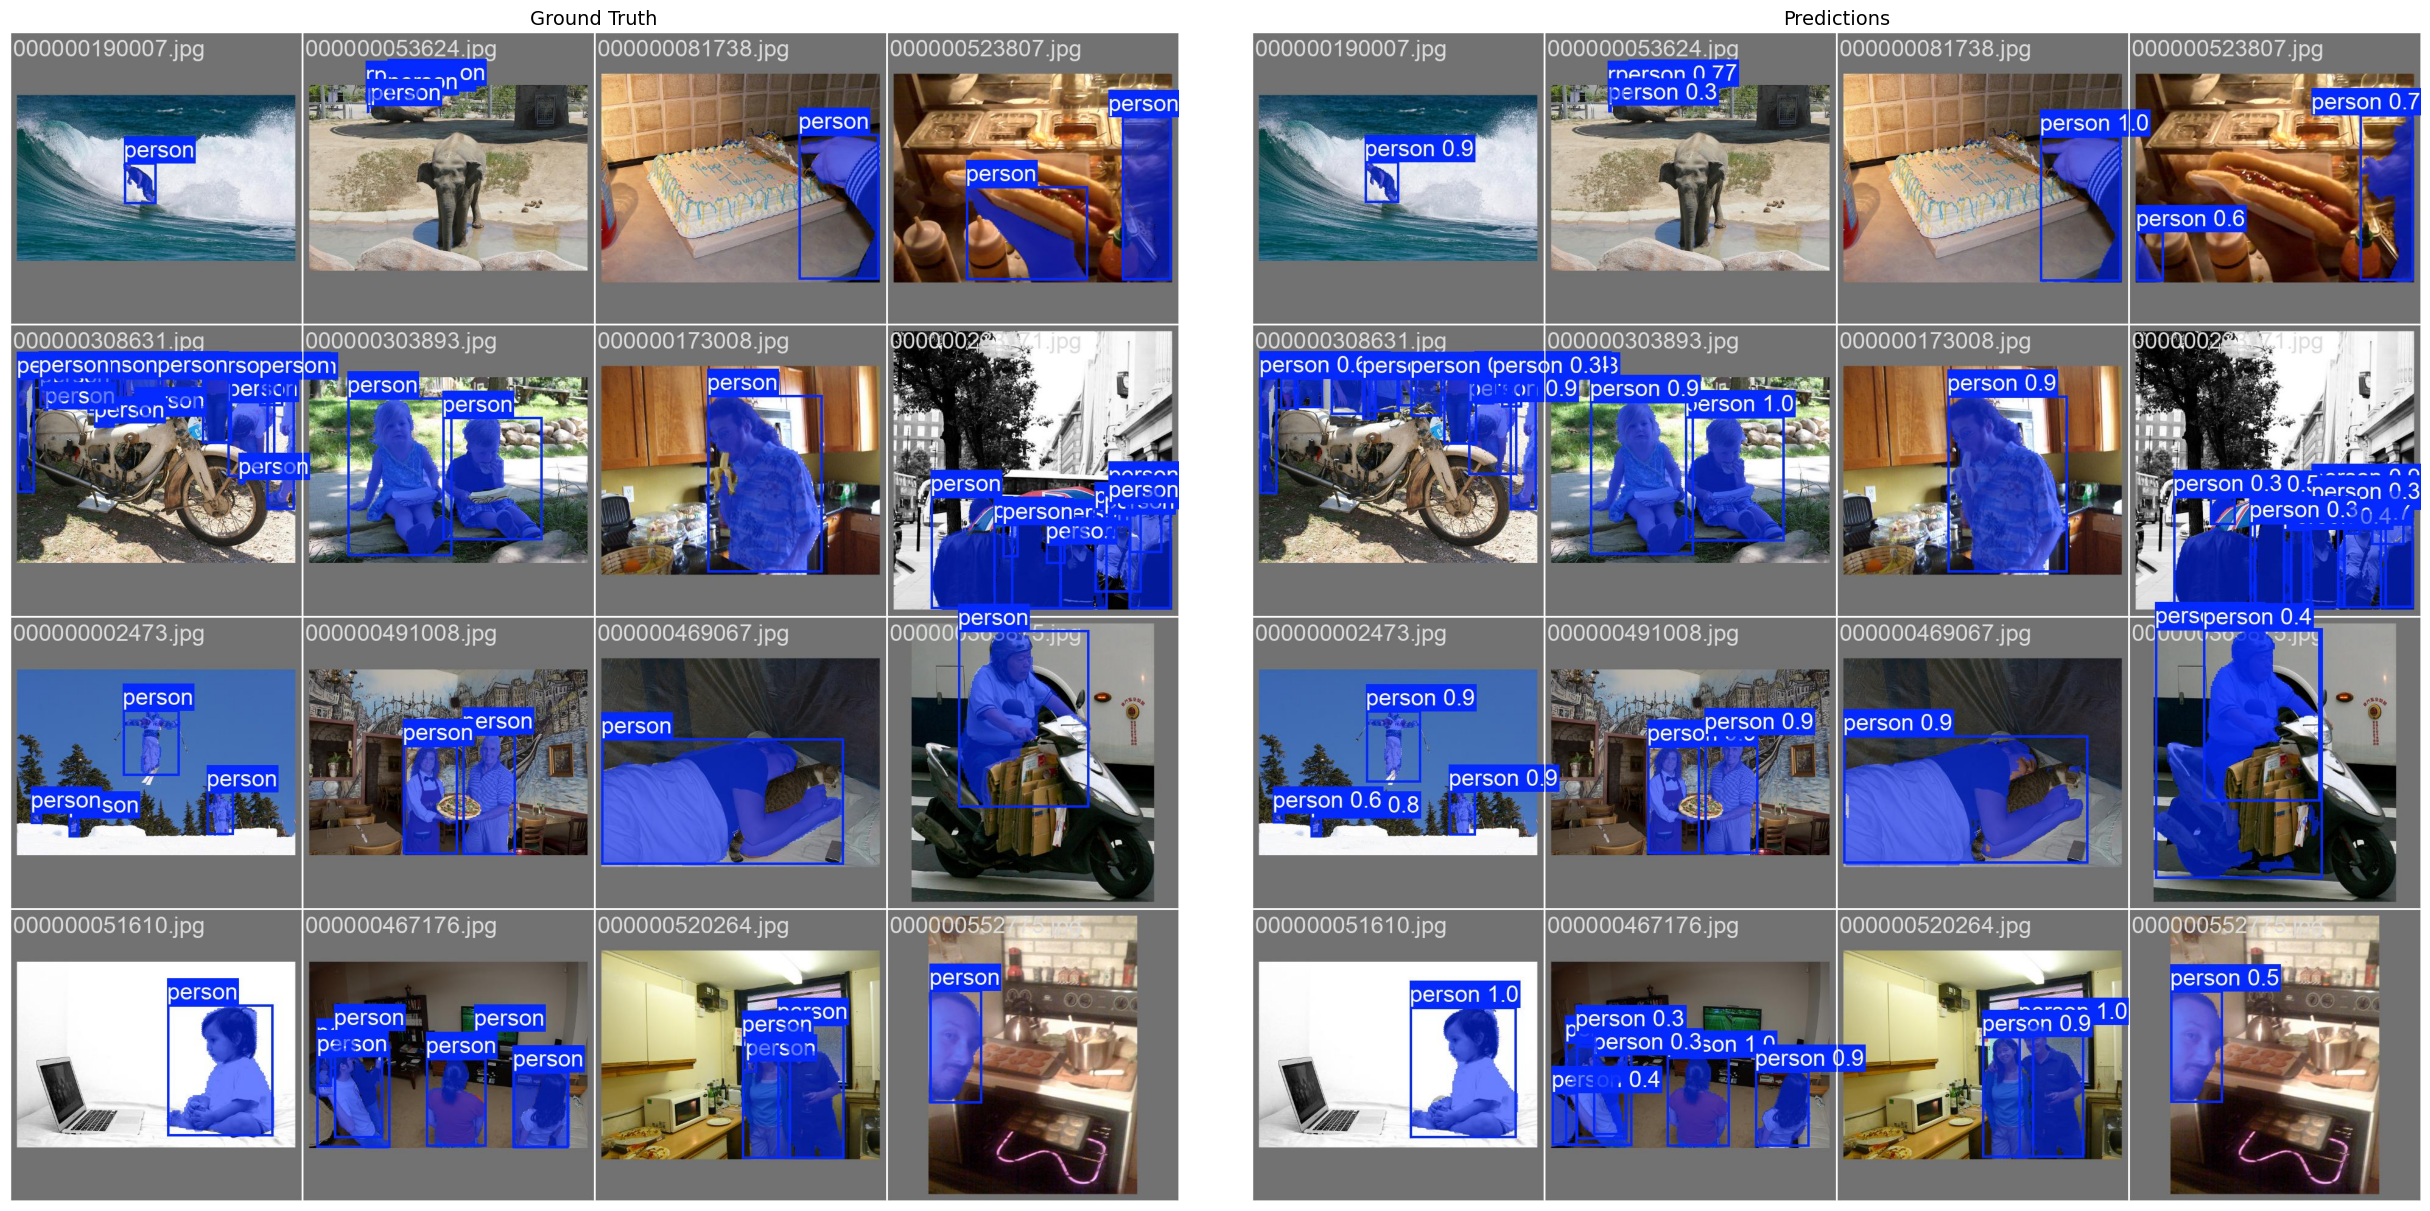

In [20]:
# примеры визуализации
plot_val_batch_results()

In [ ]:
from ultralytics.utils import clean_project_dir
clean_project_dir()  # удаляем старые!!! runs/ кроме последних 3 экспериментов

#### Задача по сегментации с YOLO
В предложенном к обучению датасете coco2017 в папке test файлы аннотаций были не заполнены, поэтому оценку модели делал на данных val2017, там всего 16 

изображений...

Для обучения пробовал модели yolov8n yolov8m yolov8l, лучшие показатели метрик у модели yolov8m. 

Параметр optimizer='SGD', показал лучшие результаты чем 'AdamW', хотя в обзорах пишут что 'AdamW' лучше для сегментации.
Пробовал применять аугментацию и менял порог для масок (0.3 вместо 0.5) и шаг learning rate.

#### В итоге модель yolov8m-seg.pt показала следующие результаты:

Average IoU: 0.5547

Average Precision: 0.9582

Average Recall: 0.5704

#### Показатели метрик лучшей модели best.pt методом val()

mAP50-95: 0.6504 

Mask mAP50: 0.7817 (Точность масок IoU=0.5)

Precision: 0.9227

Recall: 0.6290
